In [8]:
# --- Cell 1: การนำเข้าไลบรารีที่จำเป็น ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pyprojroot import here

# Libraries สำหรับ Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Library สำหรับจัดการ Imbalanced Data (ลด Selection Bias)
from imblearn.over_sampling import SMOTE

# ปรับแต่งกราฟให้สวยงามและอ่านง่าย
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [9]:
# --- Cell 2: โหลดข้อมูลและกำหนด Target ---
# โหลดข้อมูล Panel Data ของเกษตรกร
base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal.csv")
df = pd.read_csv(file_path)

# เลือก Feature ตามทฤษฎีทุน (Human, Physical, Social Capital)
features = ['age', 'edu', 'irriga', 'All_Skill', 'land_crop1_in', 'agri Org_mem']

# 1. กำหนดตัวแปรเป้าหมายหลัก (Baseline Target): พัฒนาทักษะ > 0
df['Success_Base'] = (df['Ch_Skill'] > 0).astype(int)

# 2. กำหนดตัวแปรเป้าหมายแบบเข้มงวด (Strict Target) สำหรับ Sensitivity Analysis
# สมมติฐาน: ทักษะต้องเพิ่มขึ้นมากกว่า 0.2 คะแนน จึงจะถือว่าคุ้มค่าการลงทุน
df['Success_Strict'] = (df['Ch_Skill'] > 0.2).astype(int)

# การจัดการค่าว่าง (Imputation) เบื้องต้น
X = df[features].fillna(0) 
y_base = df['Success_Base']

print(f"สัดส่วนกลุ่มเป้าหมาย (Baseline): \n{y_base.value_counts(normalize=True) * 100}")

สัดส่วนกลุ่มเป้าหมาย (Baseline): 
Success_Base
0    52.63789
1    47.36211
Name: proportion, dtype: float64


In [10]:
# --- Cell 3: การแบ่งข้อมูลและทำ SMOTE ---
# แบ่งข้อมูลเป็น Training (80%) และ Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_base, test_size=0.2, random_state=42, stratify=y_base)

# ใช้ SMOTE ขยายกลุ่ม Minority Class (เกษตรกรที่ทักษะเพิ่มขึ้น) เฉพาะในชุด Train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"จำนวนข้อมูลก่อนทำ SMOTE: {len(y_train)}")
print(f"จำนวนข้อมูลหลังทำ SMOTE: {len(y_train_sm)}")

จำนวนข้อมูลก่อนทำ SMOTE: 667
จำนวนข้อมูลหลังทำ SMOTE: 702


=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

           0       0.71      0.58      0.64        88
           1       0.61      0.73      0.67        79

    accuracy                           0.65       167
   macro avg       0.66      0.66      0.65       167
weighted avg       0.66      0.65      0.65       167



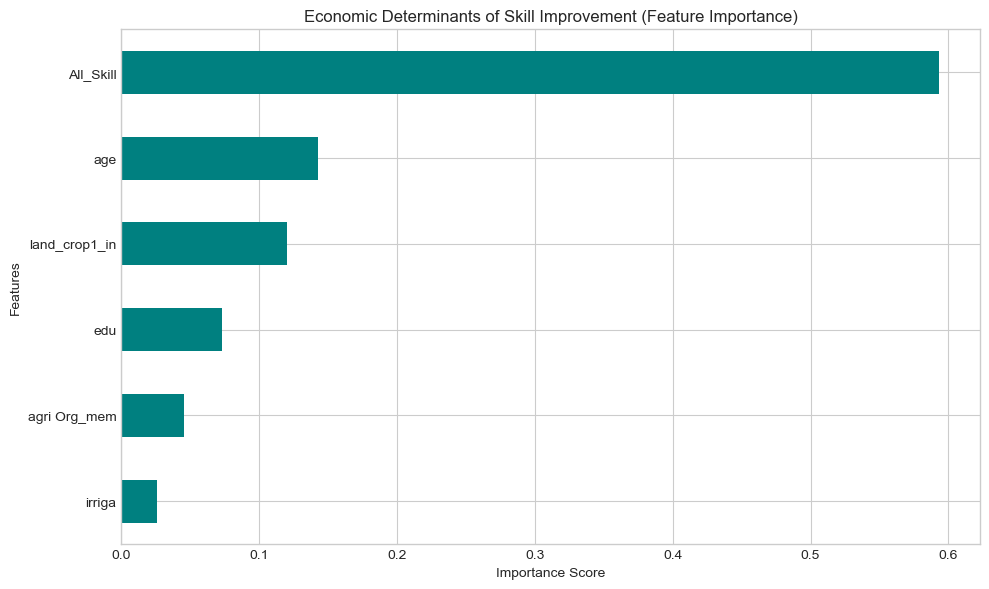

In [11]:
# --- Cell 4: Random Forest Model & Feature Importance ---
# สร้างโมเดล Ensemble เพื่อความเสถียร
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

# พยากรณ์และวัดผลบนชุด Test (เน้นพิจารณาค่า Recall ของ Class 1)
y_pred_rf = rf_model.predict(X_test)
print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))

# แสดงผล Feature Importance (ความสัมพันธ์เชิงเศรษฐศาสตร์)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Economic Determinants of Skill Improvement (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# นัยยะเชิงนโยบาย: หาก irriga หรือ All_Skill มีค่าสูง แสดงว่าโครงสร้างพื้นฐาน 
# และทุนมนุษย์เดิมคือเงื่อนไขชี้ขาดความสำเร็จ

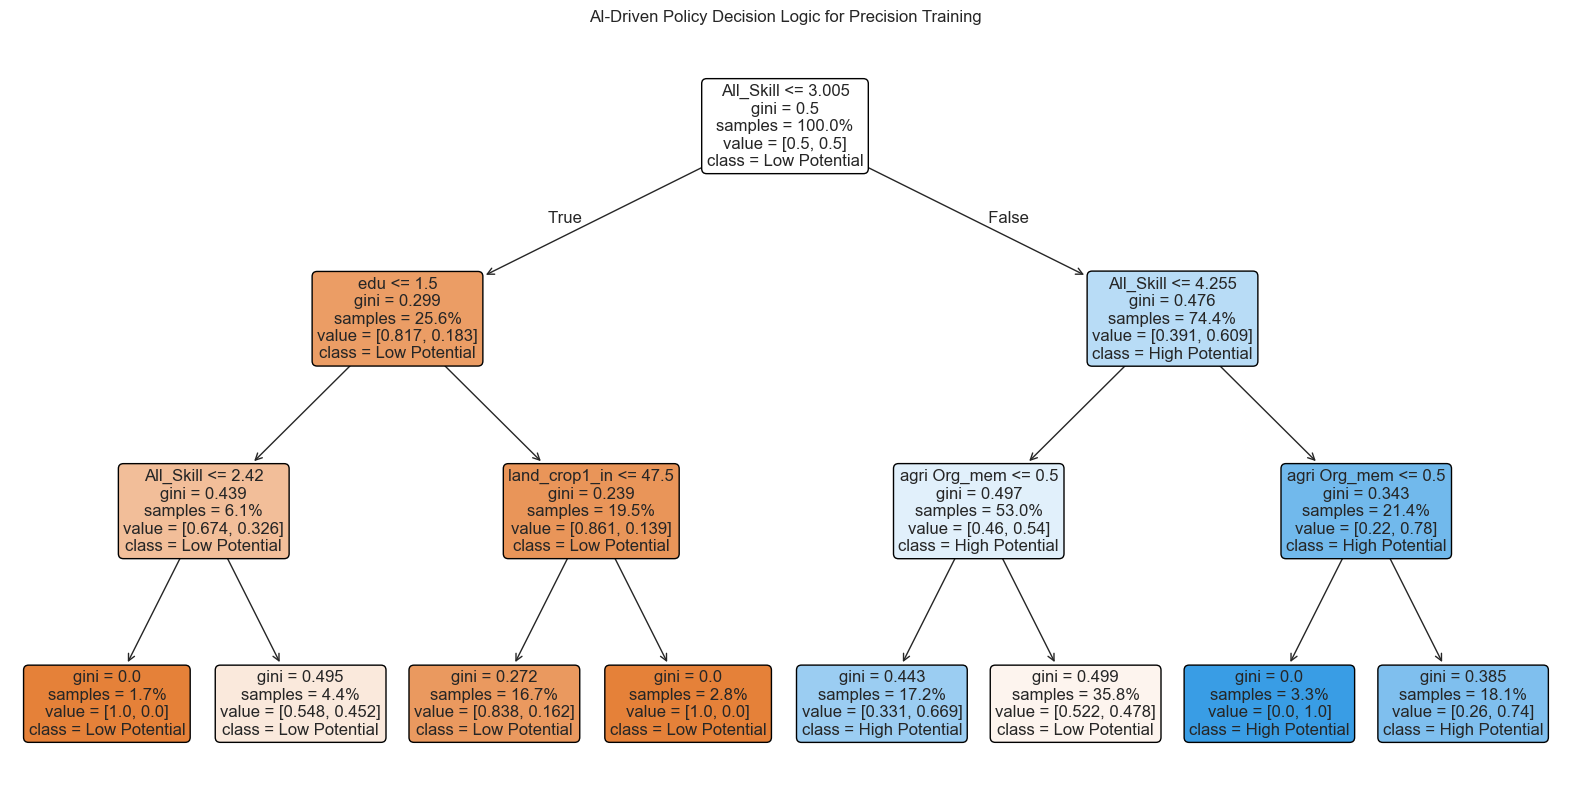

In [12]:
# --- Cell 5: Policy Decision Tree ---
# ใช้ Decision Tree ขนาดเล็ก (max_depth=3) เพื่อให้สามารถอธิบายตรรกะได้ง่าย
dt_policy = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_policy.fit(X_train_sm, y_train_sm)

# วาดผังการตัดสินใจ
plt.figure(figsize=(20, 10))
plot_tree(dt_policy, 
          feature_names=features, 
          class_names=['Low Potential', 'High Potential'], 
          filled=True, 
          rounded=True, 
          fontsize=12,
          proportion=True)
plt.title('AI-Driven Policy Decision Logic for Precision Training')
plt.show()

# คำแนะนำสำหรับการเขียน: นำเงื่อนไขในกล่อง (Nodes) เช่น All_Skill <= 3.00 
# ไปเขียนเป็นข้อเสนอแนะในการแยกเกษตรกรเข้าหลักสูตรระดับพื้นฐานและระดับสูง

In [13]:
# --- Cell 6: Sensitivity Analysis (Strict Threshold) ---
y_strict = df['Success_Strict']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_strict, test_size=0.2, random_state=42, stratify=y_strict)

X_train_sm_s, y_train_sm_s = smote.fit_resample(X_train_s, y_train_s)

rf_strict = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_strict.fit(X_train_sm_s, y_train_sm_s)

print("=== Classification Report (Strict Threshold: Ch_Skill > 0.2) ===")
print(classification_report(y_test_s, rf_strict.predict(X_test_s)))

# ตรวจสอบ Feature Importance ของโมเดลที่เข้มงวด
strict_importances = pd.Series(rf_strict.feature_importances_, index=features)
print("\nFeature Importances (Strict Model):")
print(strict_importances.sort_values(ascending=False))

# นัยยะเชิงวิชาการ: หากลำดับความสำคัญของตัวแปร (เช่น All_Skill และ irriga) 
# ยังคงเป็นอันดับต้นๆ สามารถยืนยันได้ว่าข้อค้นพบของงานวิจัยมีความเสถียร (Robust)

=== Classification Report (Strict Threshold: Ch_Skill > 0.2) ===
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       112
           1       0.48      0.58      0.53        55

    accuracy                           0.66       167
   macro avg       0.63      0.64      0.63       167
weighted avg       0.68      0.66      0.67       167


Feature Importances (Strict Model):
All_Skill        0.558678
age              0.127014
land_crop1_in    0.119804
agri Org_mem     0.112247
edu              0.057699
irriga           0.024558
dtype: float64
